In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import anafibre as fib
from anafibre.plotting import add_visible_spectrum, plot_dispersion_chart
import astropy.units as u
import astropy.constants as co

In [2]:
# This script sets up a step-index fibre with specific parameters.
fibre = fib.StepIndexFibre(
    core_radius = 200*u.nm, 
    eps_core = 4,    
    eps_clad = 1,    
    mu_core  = 1,    
    mu_clad  = 1   
) 

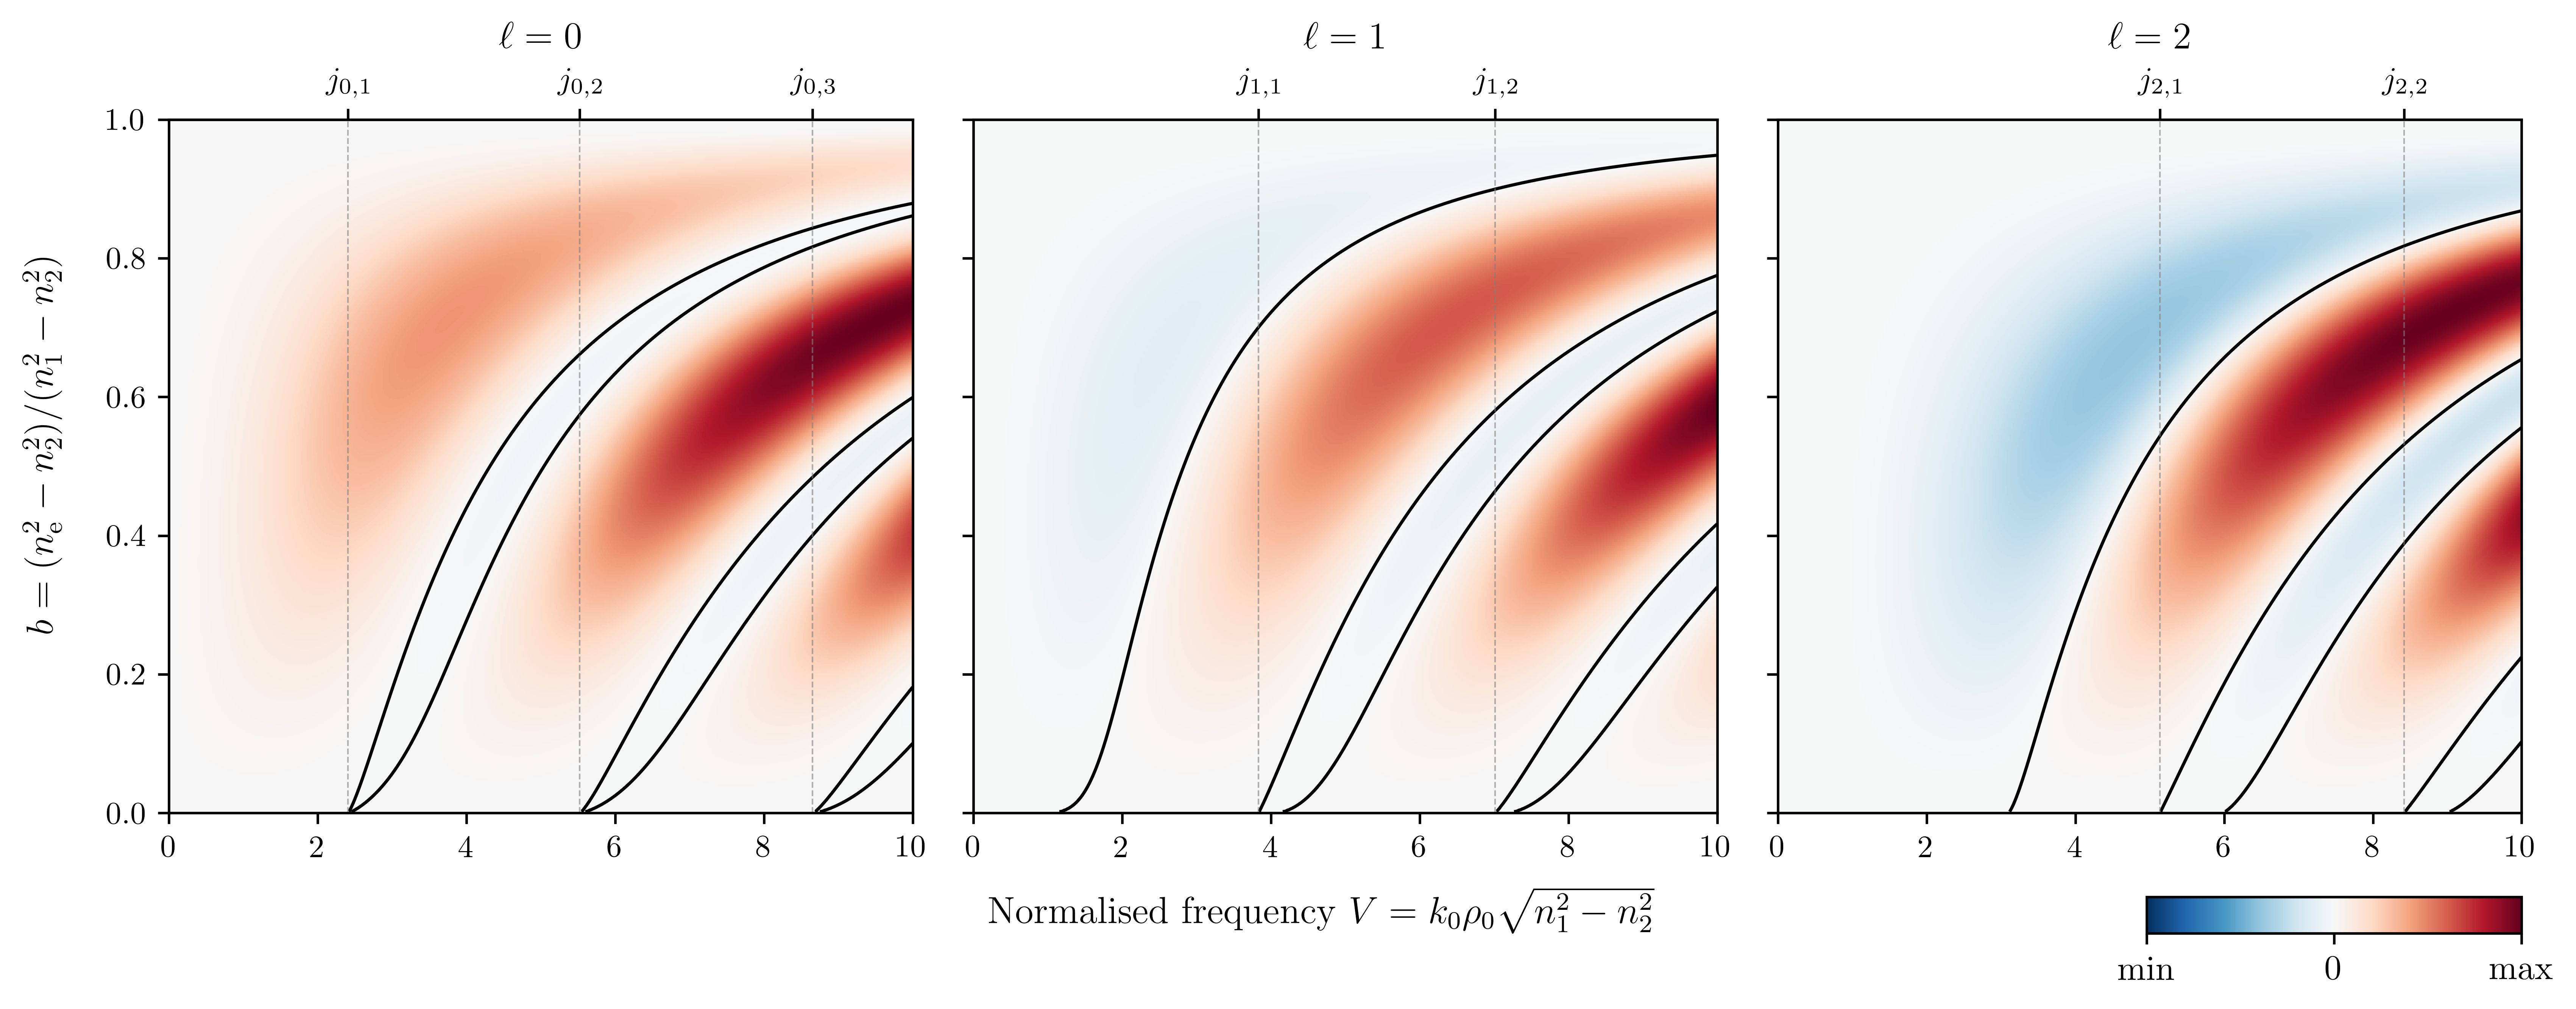

In [3]:
import matplotlib as mpl
# mpl.use("pgf")
mpl.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
})
# plt.rcParams.update({
#     "font.size": 14,          # base font size
#     "axes.titlesize": 16,     # subplot titles
#     "axes.labelsize": 16,     # axis labels
#     "xtick.labelsize": 13,
#     "ytick.labelsize": 13,
#     "legend.fontsize": 13,
# })
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True, dpi=300)
ells = [0, 1, 2]
for i, (ax, ell) in enumerate(zip(axes, ells)):
    plot_dispersion_chart(
        fibre, ell=ell, ax=ax,
        ylabel=False,     
        xlabel=False,
        Vmin=0
    )
    ax.set_title(rf"$\ell = {ell}$")
fig.supxlabel(r"Normalised frequency $V=k_0\rho_0\sqrt{n_1^2 - n_2^2}$", y=-0.04)
fig.supylabel(r"$b = (n_\mathrm{e}^2-n_2^2)/(n_1^2-n_2^2)$", x=-0.02)

# Create a dummy ScalarMappable from -1 to 1, colormap as in your plot
dummy_norm = mpl.colors.Normalize(vmin=-1, vmax=1)
dummy_sm = mpl.cm.ScalarMappable(norm=dummy_norm, cmap='RdBu_r')

# Place the colorbar wherever you want; tweak [left, bottom, width, height]
cbar_ax = fig.add_axes([.83, -0.04, 0.15, 0.04])  # Adjust as needed!

cb = fig.colorbar(dummy_sm, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([-1, 0, 1])
cb.set_ticklabels(['min', '0', 'max'])
cb.ax.tick_params(labelsize=11)

# plt.tight_layout()
# plt.show()
plt.savefig("dispersion.pdf", bbox_inches="tight", dpi=300)

[]

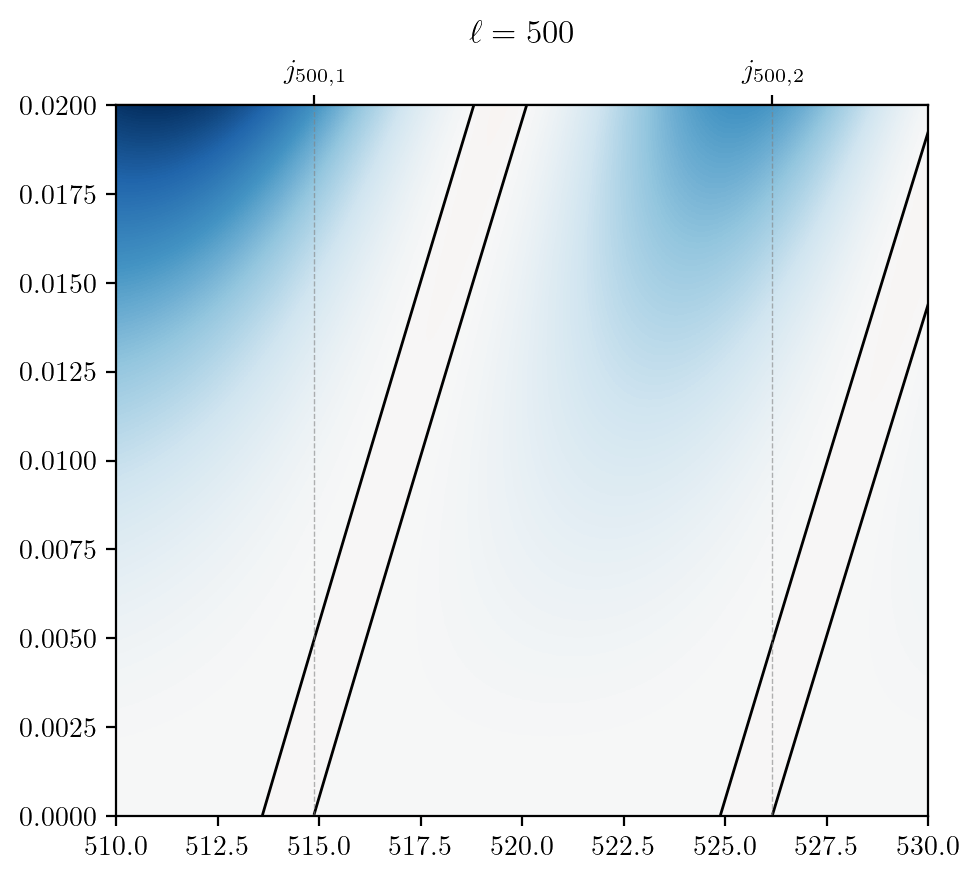

In [4]:
plot_dispersion_chart(
        fibre, ell=500,
        ylabel=False,     
        xlabel=False,
        Vmax=530,
        Vmin=510,
        bmin=0,#np.finfo(float).eps,
        bmax=.02,
        Npoints=1000,
        # colorbar=True
    )
plt.plot()

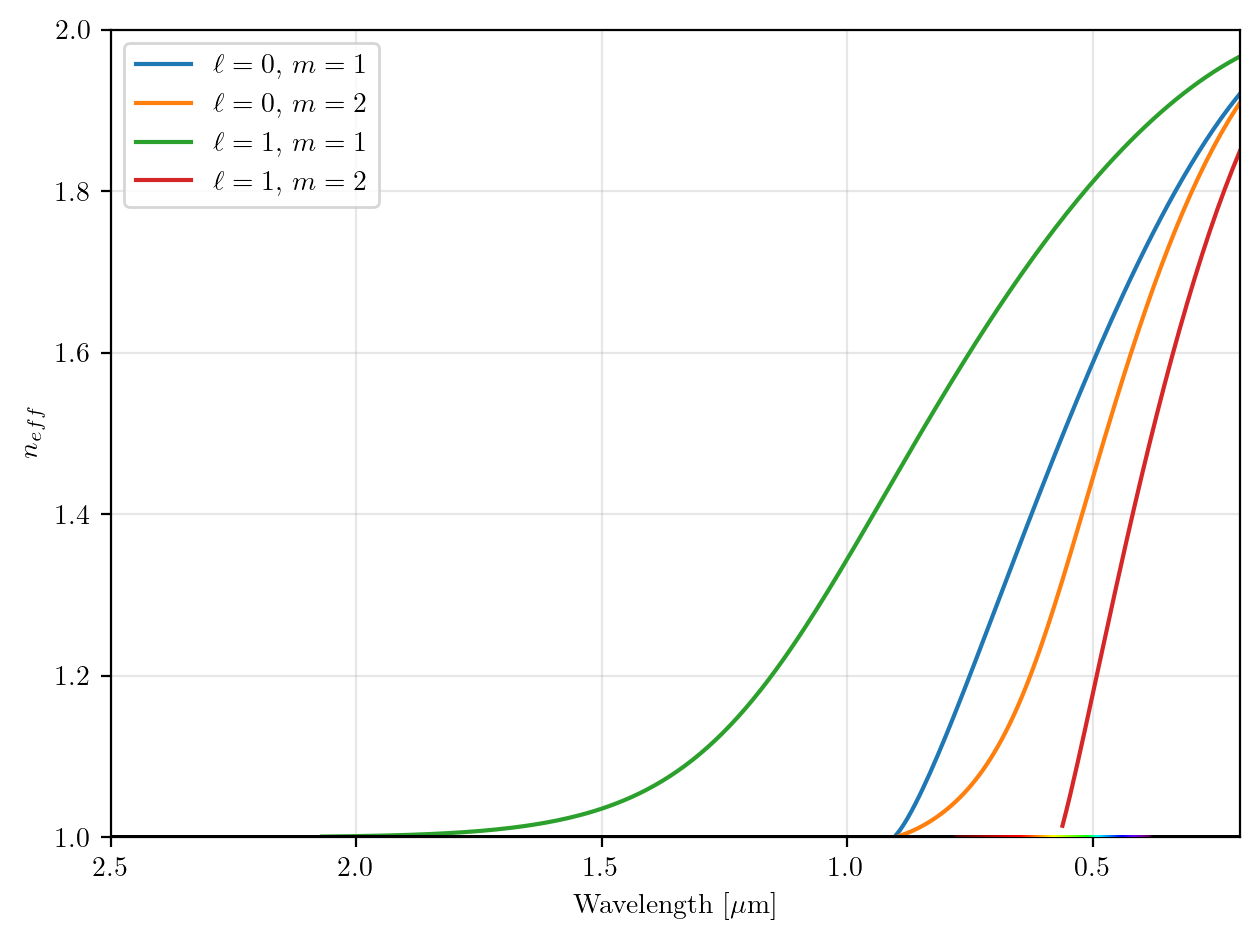

In [5]:
# Set up wavelength grid
wlgrid = np.linspace(2.500, 0.200, 300) * u.um  # Wavelength grid from 2.5 μm to 0.1 μm

fig, ax = plt.subplots()
for ell in [0, 1]:
    for m in [1, 2]:
        b_mode = fibre.neff(ell=ell, m=m, V=fibre.V(wlgrid))
        ax.plot(wlgrid.value, b_mode, label=fr"$\ell={ell}$, $m={m}$")
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$n_{eff}$")
ax.set_ylim(fibre.n_clad(1), fibre.n_core(1))
ax.set_xlim(wlgrid.value[0], wlgrid.value[-1])
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()


add_visible_spectrum(ax,position=[0, 0, 1, 0.0025], wavelengths=wlgrid.to_value(u.nm))


plt.show()


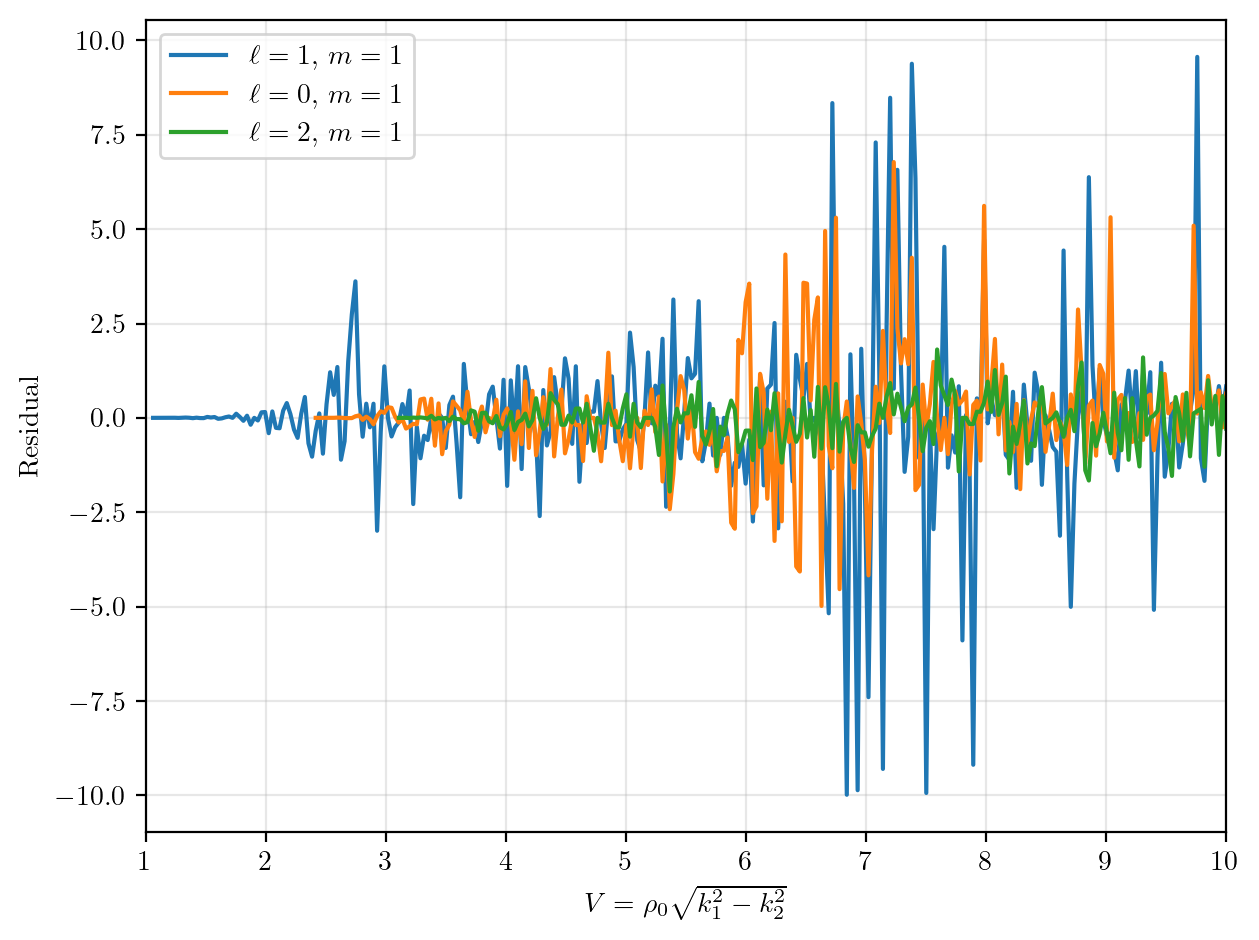

In [6]:
# Set up V grid
Vgrid = np.linspace(1, 10, 300)  # Choose range suitable for your fibre

fig, ax = plt.subplots()
for ell in [1,0,2]:
    for m in [1]:
        b_mode = fibre.b(ell=ell, m=m, V=Vgrid)
        residual = fibre.F(ell, b_mode, V=Vgrid)/np.finfo(float).eps
        ax.plot(Vgrid, residual, label=fr"$\ell={ell}$, $m={m}$")

plt.xlabel(r"$V = \rho_0 \sqrt{k_1^2 - k_2^2}$")
plt.ylabel(r"Residual")
# plt.ylim(1e-15, 1e-15)
plt.xlim(Vgrid[0], Vgrid[-1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
ax.legend()
plt.show()

In [7]:
def b_error_estimate(fibre, ell, b_hat, *, V=None, wavelength=None, mode_type=None,
                     method="complex_step"):
    """
    A-posteriori root error estimate: |Δb| ≈ |F|/|F'| at b_hat.
    Works with scalars or arrays; returns same shape as b_hat.
    """
    b_hat = np.asarray(b_hat)
    if V is not None:
        V = np.asarray(V)

    def F(bb):
        return fibre.F(ell=ell, b=bb, V=V, wavelength=wavelength, mode_type=mode_type)

    # Residual
    r = F(b_hat)
    abs_r = np.abs(r)

    if method == "complex_step":
        # Complex-step derivative (safe if your F tolerates tiny imaginary parts)
        h = 1e-30 * (1.0 + np.abs(b_hat))          # broadcastable
        fp = np.imag(F(b_hat + 1j*h)) / h
    else:
        # Symmetric finite difference with scale-aware, interval-safe step
        h0 = np.sqrt(np.finfo(float).eps) * (1.0 + np.abs(b_hat))
        # keep step inside [0,1] per element
        inside = (b_hat > 0.0) & (b_hat < 1.0)
        hcap = 0.5 * np.minimum(b_hat, 1.0 - b_hat)
        h = np.where(inside, np.minimum(h0, hcap), h0)

        fp = (F(b_hat + h) - F(b_hat - h)) / (2.0*h)

    abs_fp = np.abs(fp)

    # Safe divide: inf where derivative is 0 or non-finite
    err = np.full_like(abs_fp, np.inf, dtype=float)
    good = np.isfinite(abs_fp) & (abs_fp > 0) & np.isfinite(abs_r)
    err[good] = abs_r[good] / abs_fp[good]

    return err

C:\Users\Sebastian\OneDrive - King's College London\Projects\2025_Anafibre\anafibre\src\anafibre\dispersion.py:59: RuntimeWarning: invalid value encountered in sqrt
  ne = np.sqrt(b * n1**2 + (1 - b) * n2**2)
C:\Users\Sebastian\OneDrive - King's College London\Projects\2025_Anafibre\anafibre\src\anafibre\dispersion.py:60: RuntimeWarning: invalid value encountered in sqrt
  sqb = np.sqrt(b)
C:\Users\Sebastian\OneDrive - King's College London\Projects\2025_Anafibre\anafibre\src\anafibre\dispersion.py:61: RuntimeWarning: invalid value encountered in sqrt
  sqb1 = np.sqrt(1 - b)
C:\Users\Sebastian\OneDrive - King's College London\Projects\2025_Anafibre\anafibre\src\anafibre\dispersion.py:93: RuntimeWarning: invalid value encountered in less
  wDlnK[w < np.finfo(float).eps] = np.nan


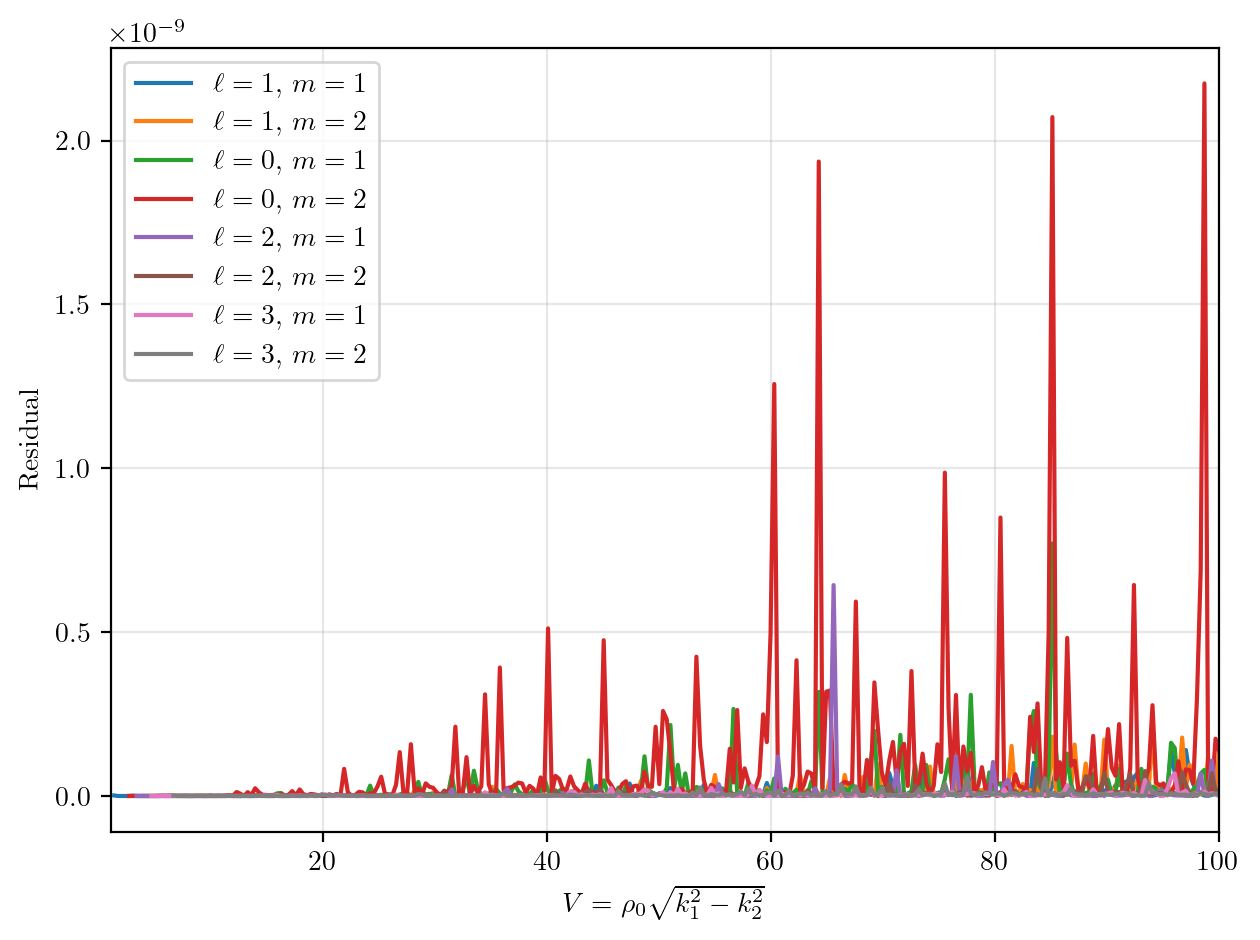

In [8]:
# Set up V grid
Vgrid = np.linspace(1, 100, 300)  # Choose range suitable for your fibre

fig, ax = plt.subplots()
for ell in [1,0,2,3]:
    for m in [1,2]:
        b_mode = fibre.b(ell=ell, m=m, V=Vgrid)
        b_error = b_error_estimate(fibre, ell, b_mode, V=Vgrid)/np.finfo(float).eps
        ax.plot(Vgrid, b_error, label=fr"$\ell={ell}$, $m={m}$")

plt.xlabel(r"$V = \rho_0 \sqrt{k_1^2 - k_2^2}$")
plt.ylabel(r"Residual")
# plt.ylim(1e-15, 1e-15)
plt.xlim(Vgrid[0], Vgrid[-1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
ax.legend()
plt.show()

In [9]:
# import mpmath as mp

# def F_dispersion_mp(fibre, ell, b, V, prec=50, mode_type=None):
#     """
#     High-precision version of F_dispersion using mpmath.
    
#     Parameters
#     ----------
#     fibre : StepIndexFibre
#     ell : int
#         Azimuthal mode index ℓ
#     b : float
#         Normalized propagation constant b ∈ [0,1]
#     V : float
#         Normalized frequency
#     prec : int
#         Decimal digits of precision
#     mode_type : str or None
#         'TE', 'TM', or None for hybrid
    
#     Returns
#     -------
#     mp.mpf
#         High-precision value of dispersion function
#     """
#     mp.mp.dps = prec  # set precision
    
#     b = mp.mpf(b)
#     V = mp.mpf(V)

#     # Refractive indices and parameters
#     wl = fibre.wavelength_from_V(float(V))  # still use float to index the models
#     n1 = fibre.n_core(wl)
#     n2 = fibre.n_clad(wl)

#     eps1 = fibre._eval(fibre.eps_core, wl)
#     eps2 = fibre._eval(fibre.eps_clad, wl)
#     mu1 = fibre._eval(fibre.mu_core, wl)
#     mu2 = fibre._eval(fibre.mu_clad, wl)

#     ne = mp.sqrt(b * n1**2 + (1 - b) * n2**2)
#     u = V * mp.sqrt(1 - b)
#     w = V * mp.sqrt(b)

#     # Bessel terms
#     Jl_u    = mp.besselj(ell, u)
#     Jlp_u   = mp.diff(lambda x: mp.besselj(ell, x), u)
#     Kl_w    = mp.besselk(ell, w)
#     Klp_w   = mp.diff(lambda x: mp.besselk(ell, x), w)

#     # φ terms
#     phi_eps = (u * w / V)**2 * (eps1 / u * Jlp_u / Jl_u + eps2 / w * Klp_w / Kl_w)
#     phi_mu  = (u * w / V)**2 * (mu1 / u * Jlp_u / Jl_u + mu2 / w * Klp_w / Kl_w)

#     if ell == 0 and mode_type is not None:
#         mt = mode_type.lower()
#         if mt == "te":
#             return phi_mu * Jl_u
#         elif mt == "tm":
#             return phi_eps * Jl_u
#         else:
#             raise ValueError("mode_type must be 'TE', 'TM', or None for ell=0.")
#     else:
#         return (phi_eps * phi_mu - (ell * ne)**2) * Jl_u**2

In [10]:

# # --- Plot setup ---
# Vgrid = np.linspace(1, 5.5, 300)
# fig, ax = plt.subplots()

# # Optional: tqdm for loop progress
# for ell in [1, 0, 2, 3]:
#     for m in [1, 2]:
#         b_mode = fibre.b(ell=ell, m=m, V=Vgrid)

#         residuals = []
#         for V, b in zip(Vgrid, b_mode):
#             try:
#                 Fval = F_dispersion_mp(fibre, ell, b, V, prec=80)
#                 residuals.append(float(Fval))  # Convert mpf to float for plotting
#             except Exception:
#                 residuals.append(np.nan)  # Handle any singularities

#         ax.plot(Vgrid, residuals, label=fr"$\ell={ell}, m={m}$")

# # --- Finalize plot ---
# plt.xlabel(r"$V = \rho_0 \sqrt{k_1^2 - k_2^2}$")
# plt.ylabel("Residual")
# plt.xlim(Vgrid[0], Vgrid[-1])
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# ax.legend()
# plt.show()

C:\Users\Sebastian\AppData\Local\Temp\ipykernel_14644\3017810493.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


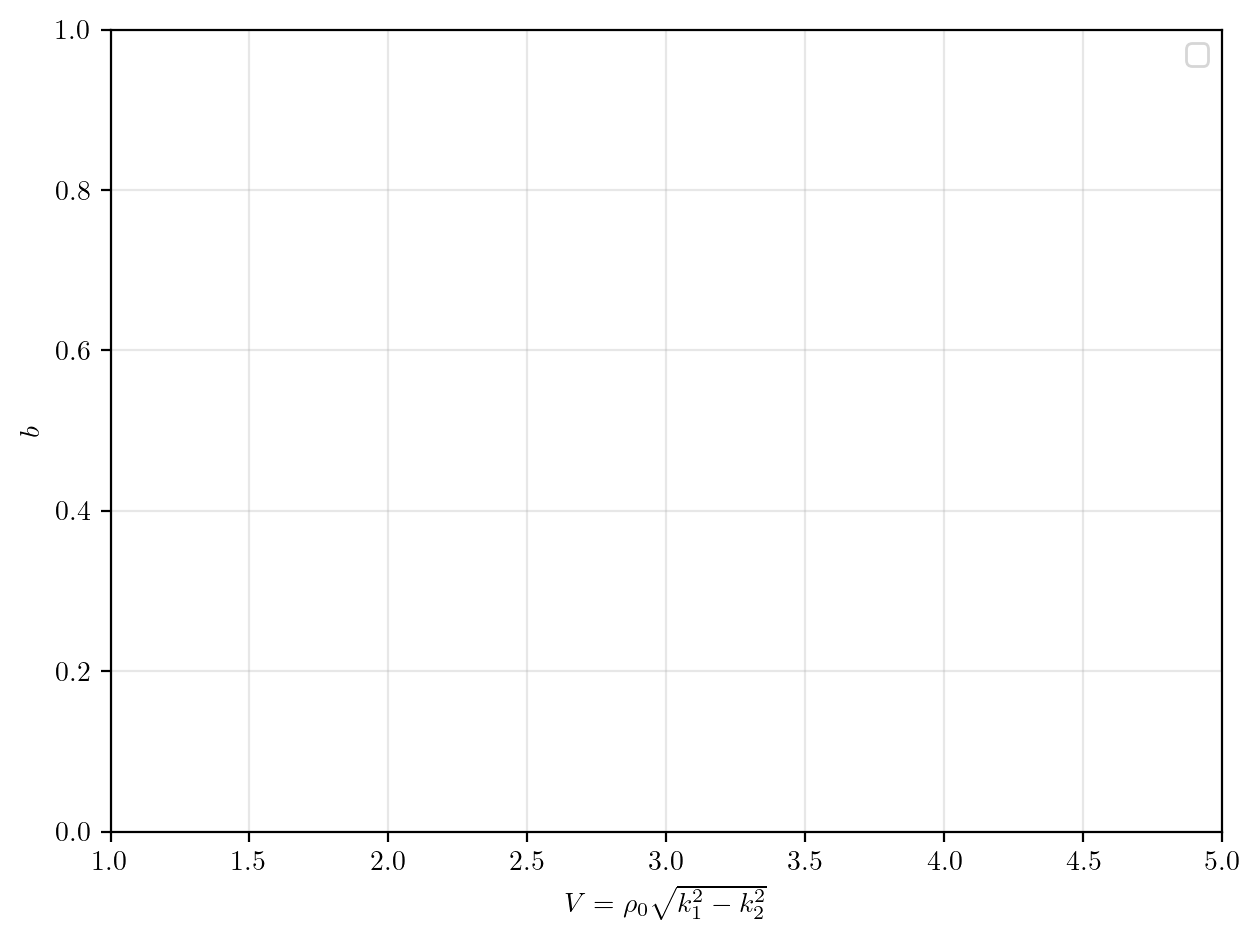

In [11]:
# Set up V grid
Vgrid = np.linspace(1, 5.0, 300)  # Choose range suitable for your fibre
ell_max = fibre.ell_max(Vgrid[-1])

fig, ax = plt.subplots()

for ell in range(ell_max + 1):
    m_max = fibre.m_max(ell, Vgrid[-1])
    for m in range(1, m_max + 1):
        b_mode = fibre.b(ell=ell, m=m, V=Vgrid)
        ax.plot(Vgrid, b_mode, label=fr"$\ell={ell}$, $m={m}$")

plt.xlabel(r"$V = \rho_0 \sqrt{k_1^2 - k_2^2}$")
plt.ylabel(r"$b$")
plt.ylim(0, 1)
plt.xlim(Vgrid[0], Vgrid[-1])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# # Calculate k0 and kz for the given b_mode and Vgrid
# Vgrid = np.linspace(1, 5.5, 300)
# k0 = Vgrid / (fibre.core_radius*np.sqrt(fibre.n_core(1)**2 - fibre.n_clad(1)**2))  # [1/m], since V = k0 * core_radius * sqrt(n1^2 - n2^2)

# fig, ax = plt.subplots()
# for ell in [0, 1, 2, 3]:
#     for m in [1, 2, 3, 4]:
#         kz = fibre.kz(ell=ell, m=m, V=Vgrid)
#         if np.isnan(kz).all():
#             continue
#         else:
#             ax.plot(k0, kz, label=fr"$\ell={ell}$, $m={m}$")
# ax.plot(k0, fibre.n_core(1) * k0, 'k--', label='n_core', lw=1)
# ax.plot(k0, fibre.n_clad(1) * k0, 'k--', label='n_clad', lw=1)
# ax.set_xlim(k0[0], k0[-1])
# ax.set_xlabel(r"$k_0$ [rad/m]")
# ax.set_ylabel(r"$k_z$ [rad/m]")
# ax.grid(True, alpha=0.3)
# ax.legend()
# plt.tight_layout()
# plt.show()


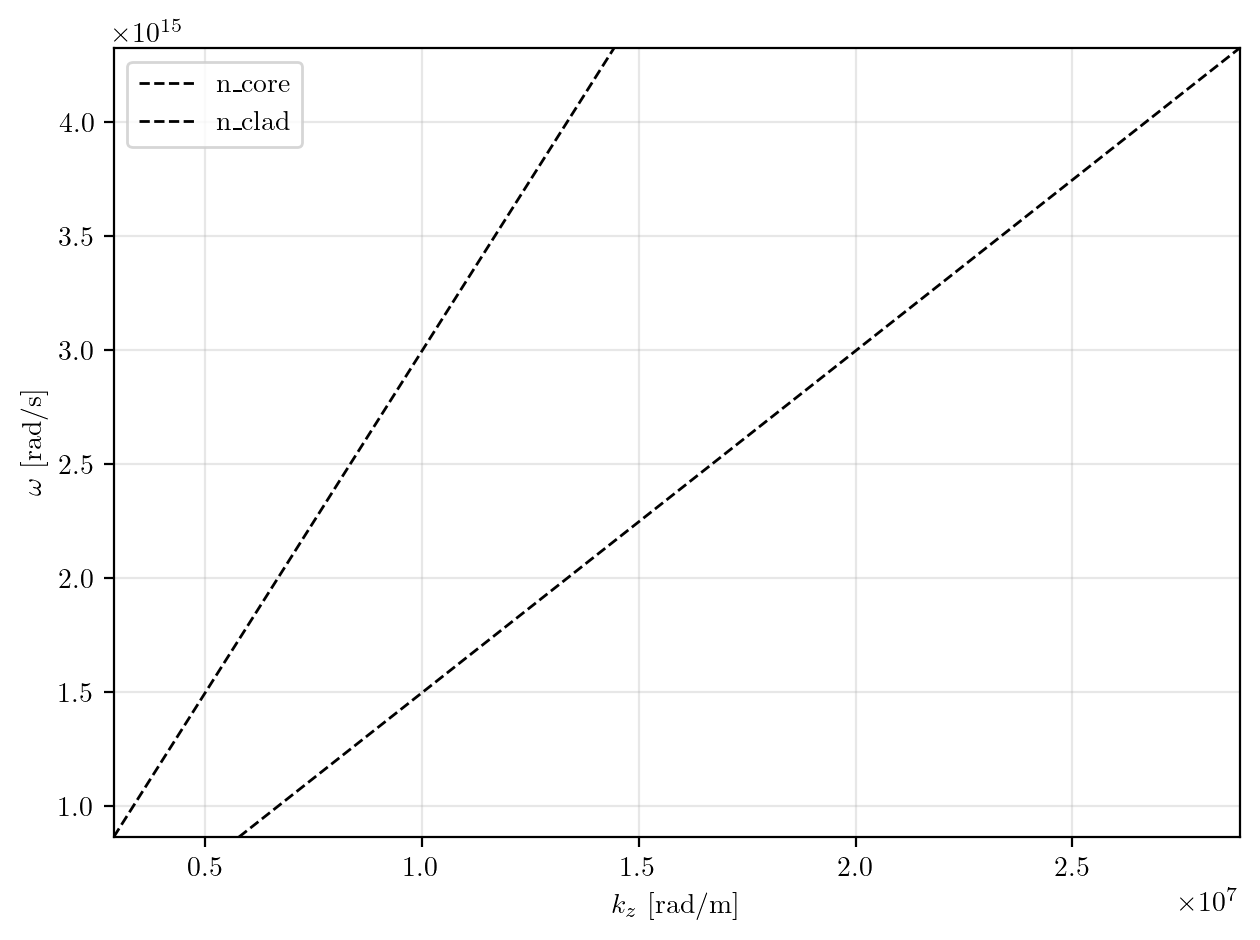

In [13]:
# Calculate k0 and kz for the given b_mode and Vgrid
Vgrid = np.linspace(1, 5.0, 300)
k0 = Vgrid / (fibre.core_radius*u.m*np.sqrt(fibre.n_core(1)**2 - fibre.n_clad(1)**2))
w0 = co.c * k0

fig, ax = plt.subplots()
for ell in range(ell_max + 1):
    m_max = fibre.m_max(ell, Vgrid[-1])
    for m in range(1, m_max + 1):
        kz = fibre.kz(ell=ell, m=m, V=Vgrid)
        if np.isnan(kz).all():
            continue
        else:
            ax.plot(kz, w0, label=fr"$\ell={ell}$, $m={m}$")
ax.plot(fibre.n_core(1) * k0, w0, 'k--', label='n_core', lw=1)
ax.plot(fibre.n_clad(1) * k0, w0, 'k--', label='n_clad', lw=1)
ax.set_ylim(w0[0].value, w0[-1].value)
ax.set_xlim(fibre.n_clad(1) * k0[0].value, fibre.n_core(1) * k0[-1].value)
ax.set_ylabel(r"$\omega$ [rad/s]")
ax.set_xlabel(r"$k_z$ [rad/m]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
